In [3]:

!pip install imbalanced-learn
!pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\aaa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\aaa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# ── Bibliothèques standard ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Prétraitement ───────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

# ── Modèles ─────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ── Métriques ───────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Sur-échantillonnage ─────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ── Sauvegarde du modèle ────────────────────────────────────
import joblib

# ── Style des graphiques ────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)

print('✅ Toutes les bibliothèques importées avec succès !')

✅ Toutes les bibliothèques importées avec succès !


---
## 📊 Étape 1 — Compréhension des données et Exploration (EDA)

On charge le dataset, on examine sa structure et on visualise la distribution des maladies et des symptômes.


In [3]:
# ── Chargement des données ──────────────────────────────────
# 📌 Assure-toi que Training.csv et Testing.csv sont dans le même dossier
df       = pd.read_csv('Training.csv')
df_test  = pd.read_csv('Testing.csv')

print(f'📐 Dimensions Training : {df.shape}')
print(f'📐 Dimensions Testing  : {df_test.shape}')
print(f'\n📋 Colonnes : {list(df.columns[:10])} ... ({df.shape[1]} colonnes au total)')

📐 Dimensions Training : (4920, 134)
📐 Dimensions Testing  : (42, 133)

📋 Colonnes : ['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue'] ... (134 colonnes au total)


In [4]:
# ── Aperçu des premières lignes ─────────────────────────────
df.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,muscle_wasting,vomiting,burning_micturition,spotting_ urination,fatigue,weight_gain,anxiety,cold_hands_and_feets,mood_swings,weight_loss,restlessness,lethargy,patches_in_throat,irregular_sugar_level,cough,...,lack_of_concentration,visual_disturbances,receiving_blood_transfusion,receiving_unsterile_injections,coma,stomach_bleeding,distention_of_abdomen,history_of_alcohol_consumption,fluid_overload.1,blood_in_sputum,prominent_veins_on_calf,palpitations,painful_walking,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis,Unnamed: 133
0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection,NaN
1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection,NaN
2,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection,NaN
3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection,NaN
4,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Fungal infection,NaN


In [5]:
# ── Informations générales ──────────────────────────────────
print('📋 Informations du dataset :')
df.info()
print(f'\n📈 Statistiques descriptives :')
df.describe()

📋 Informations du dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 134 entries, itching to Unnamed: 133
dtypes: float64(1), int64(132), object(1)
memory usage: 5.0+ MB

📈 Statistiques descriptives :


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,muscle_wasting,vomiting,burning_micturition,spotting_ urination,fatigue,weight_gain,anxiety,cold_hands_and_feets,mood_swings,weight_loss,restlessness,lethargy,patches_in_throat,irregular_sugar_level,cough,...,rusty_sputum,lack_of_concentration,visual_disturbances,receiving_blood_transfusion,receiving_unsterile_injections,coma,stomach_bleeding,distention_of_abdomen,history_of_alcohol_consumption,fluid_overload.1,blood_in_sputum,prominent_veins_on_calf,palpitations,painful_walking,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Unnamed: 133
count,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,...,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,4920.000000,0.0
mean,0.137805,0.159756,0.021951,0.045122,0.021951,0.162195,0.139024,0.045122,0.045122,0.021951,0.021951,0.389024,0.043902,0.021951,0.392683,0.023171,0.023171,0.023171,0.046341,0.092683,0.046341,0.092683,0.021951,0.023171,0.114634,...,0.024390,0.023171,0.023171,0.024390,0.024390,0.024390,0.024390,0.023171,0.023171,0.023171,0.024390,0.023171,0.024390,0.046341,0.021951,0.021951,0.021951,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,0.023171,NaN
std,0.344730,0.366417,0.146539,0.207593,0.146539,0.368667,0.346007,0.207593,0.207593,0.146539,0.146539,0.487578,0.204899,0.146539,0.488397,0.150461,0.150461,0.150461,0.210245,0.290017,0.210245,0.290017,0.146539,0.150461,0.318612,...,0.154273,0.150461,0.150461,0.154273,0.154273,0.154273,0.154273,0.150461,0.150461,0.150461,0.154273,0.150461,0.154273,0.210245,0.146539,0.146539,0.146539,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,0.150461,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

In [6]:
# ── Valeurs manquantes ──────────────────────────────────────
missing = df.isnull().sum()
print('❓ Valeurs manquantes :')
if missing.sum() == 0:
    print('  ✅ Aucune valeur manquante !')
else:
    print(missing[missing > 0])

# ── Doublons ────────────────────────────────────────────────
print(f'\n🔁 Nombre de doublons : {df.duplicated().sum()}')

# ── Distribution de la cible ─────────────────────────────────
print(f'\n🏥 Nombre de maladies : {df["prognosis"].nunique()}')
print('\n📊 Occurrences par maladie :')
print(df['prognosis'].value_counts())

❓ Valeurs manquantes :
Unnamed: 133    4920
dtype: int64

🔁 Nombre de doublons : 4616

🏥 Nombre de maladies : 41

📊 Occurrences par maladie :
prognosis
Fungal infection                           120
Hepatitis C                                120
Hepatitis E                                120
Alcoholic hepatitis                        120
Tuberculosis                               120
Common Cold                                120
Pneumonia                                  120
Dimorphic hemmorhoids(piles)               120
Heart attack                               120
Varicose veins                             120
Hypothyroidism                             120
Hyperthyroidism                            120
Hypoglycemia                               120
Osteoarthristis                            120
Arthritis                                  120
(vertigo) Paroymsal  Positional Vertigo    120
Acne                                       120
Urinary tract infection                    120
Ps

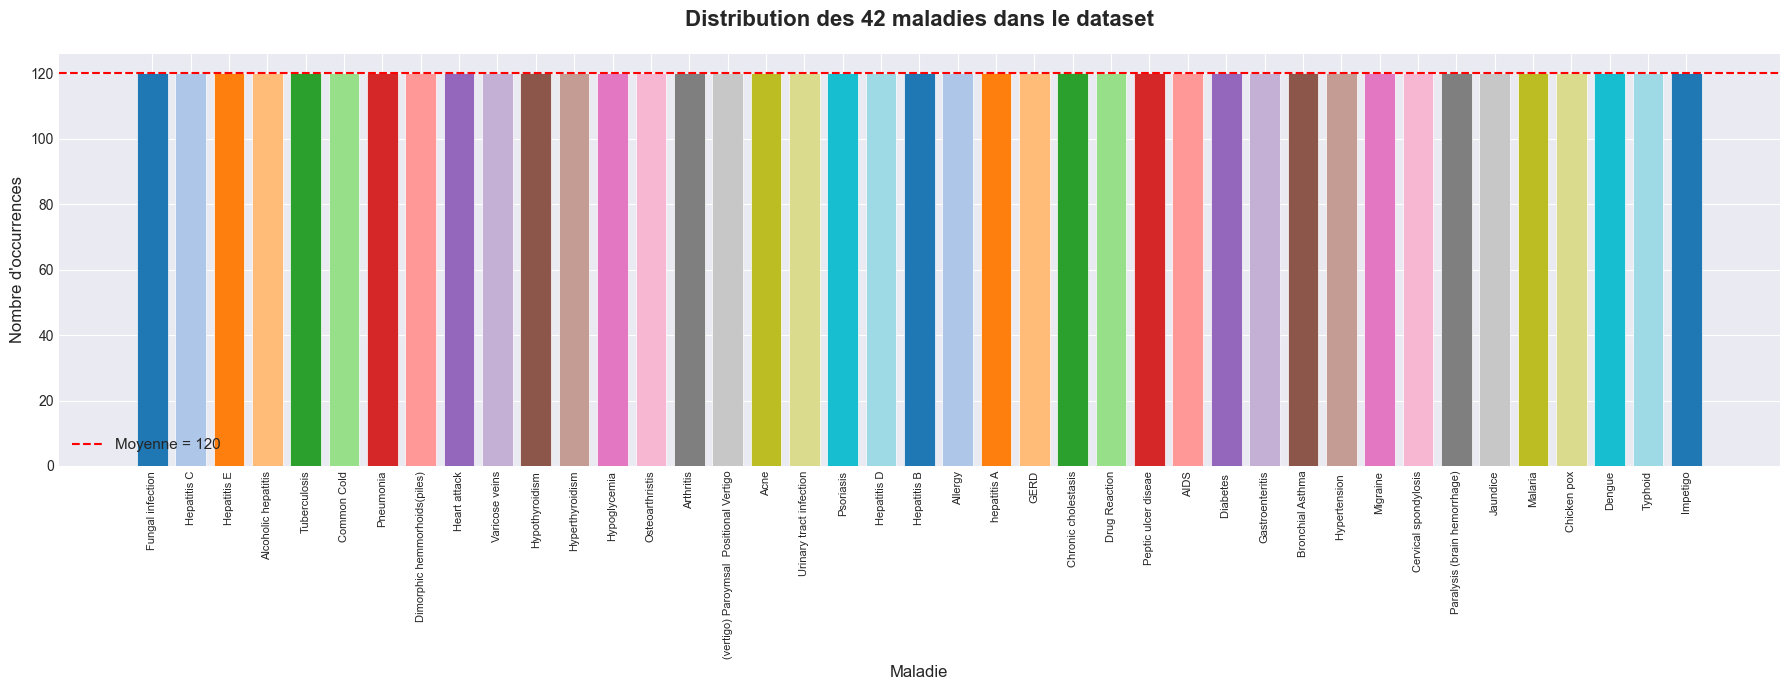

✅ Graphique sauvegardé : 01_distribution_maladies.png


In [7]:
# ── Visualisation 1 : Distribution des maladies ─────────────
fig, ax = plt.subplots(figsize=(18, 7))
counts = df['prognosis'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=plt.cm.tab20.colors * 3, edgecolor='white', linewidth=0.5)

ax.set_title('Distribution des 42 maladies dans le dataset', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Maladie', fontsize=12)
ax.set_ylabel("Nombre d'occurrences", fontsize=12)
ax.tick_params(axis='x', rotation=90, labelsize=8)
ax.axhline(y=counts.mean(), color='red', linestyle='--', label=f'Moyenne = {counts.mean():.0f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('01_distribution_maladies.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 01_distribution_maladies.png')

💊 Nombre total de symptômes : 132


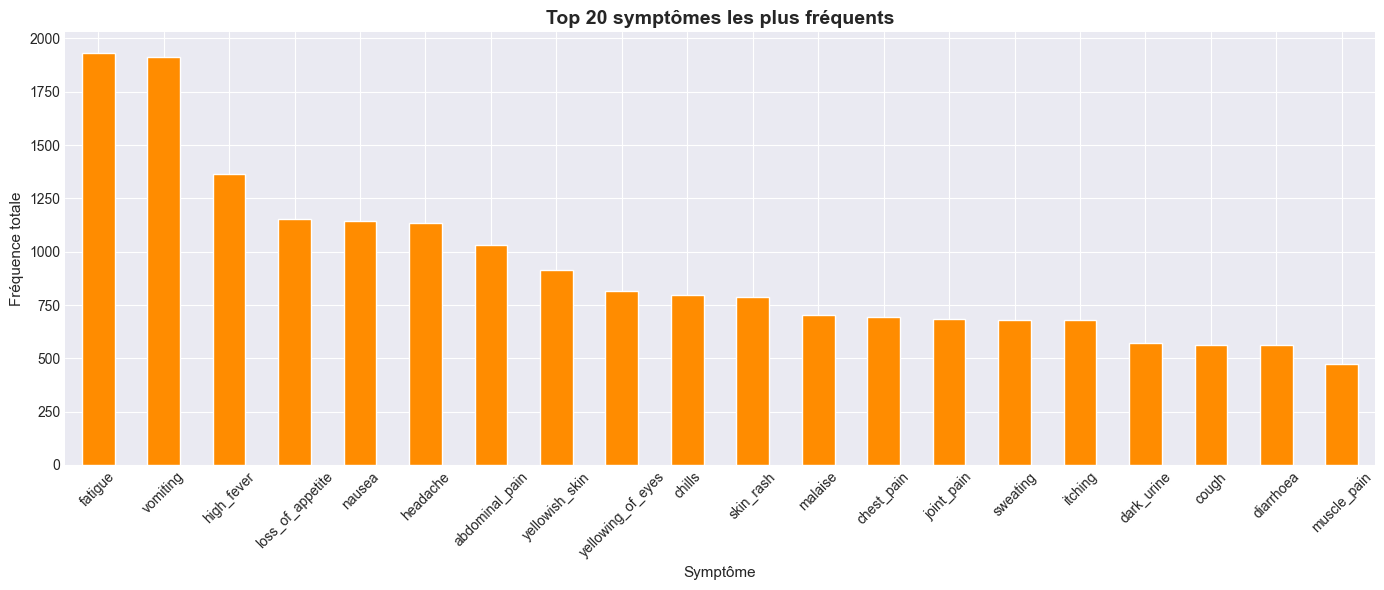

✅ Graphique sauvegardé : 02_top20_symptomes.png


In [8]:
# ── Visualisation 2 : Top 20 symptômes les plus fréquents ───
symptom_cols = [col for col in df.columns if col not in ['prognosis', 'Unnamed: 133']]
print(f'💊 Nombre total de symptômes : {len(symptom_cols)}')

top_symptoms = df[symptom_cols].sum().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
top_symptoms.plot(kind='bar', ax=ax, color='darkorange', edgecolor='white')
ax.set_title('Top 20 symptômes les plus fréquents', fontsize=14, fontweight='bold')
ax.set_xlabel('Symptôme', fontsize=11)
ax.set_ylabel('Fréquence totale', fontsize=11)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('02_top20_symptomes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 02_top20_symptomes.png')

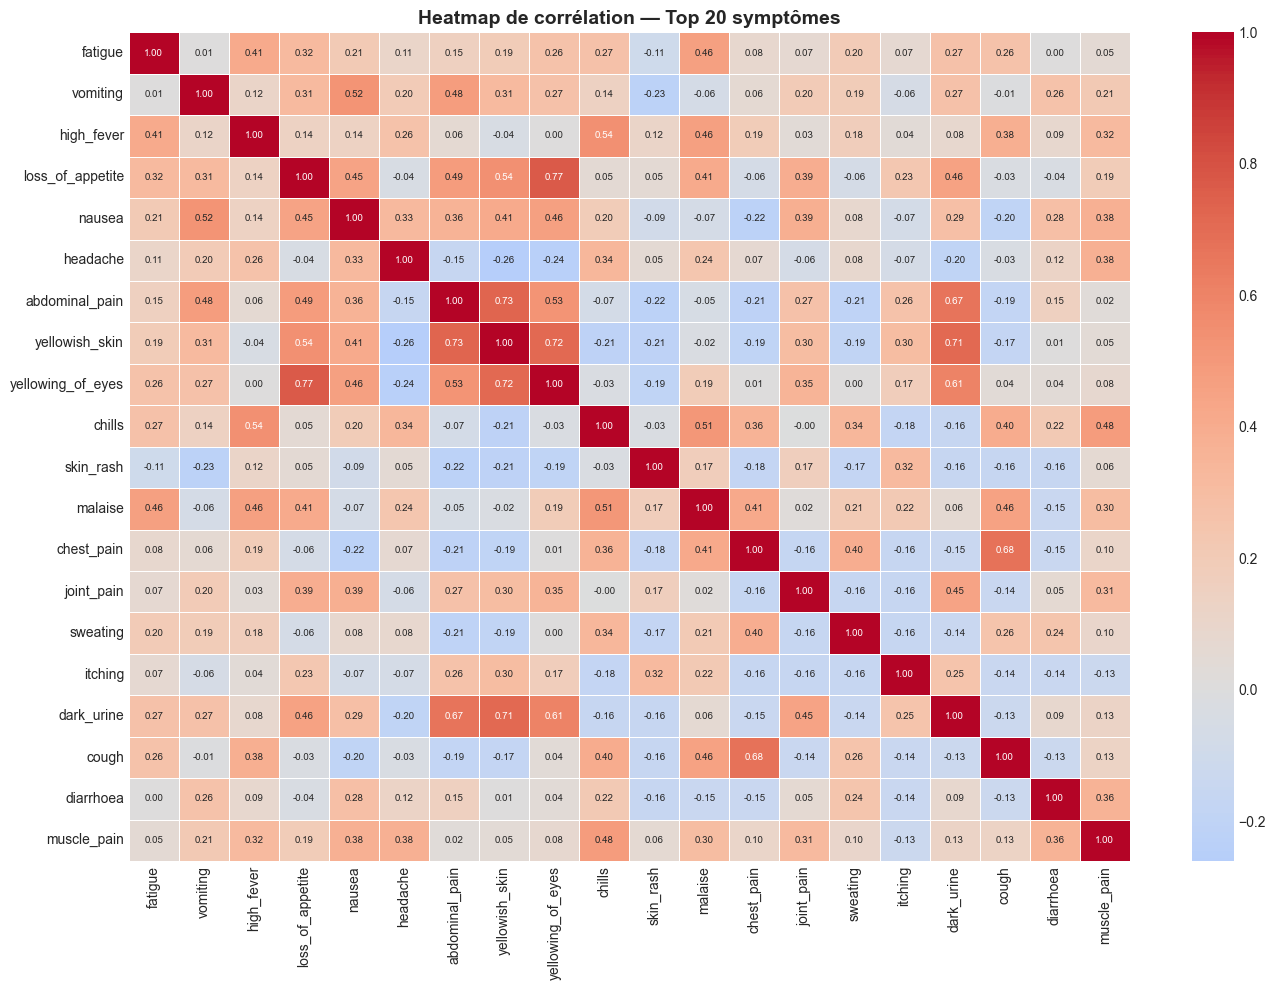

✅ Graphique sauvegardé : 03_heatmap_correlation.png


In [9]:
# ── Visualisation 3 : Heatmap corrélation (top 20 symptômes) ─
top20_cols = df[symptom_cols].sum().sort_values(ascending=False).head(20).index.tolist()
corr_matrix = df[top20_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 7})
ax.set_title('Heatmap de corrélation — Top 20 symptômes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 03_heatmap_correlation.png')

---
## 🧹 Étape 2 — Nettoyage et imputation des valeurs manquantes


In [11]:
# ── Suppression de la colonne inutile ────────────────────────
if 'Unnamed: 133' in df.columns:
    df = df.drop(columns=['Unnamed: 133'])
    print('✅ Colonne "Unnamed: 133" supprimée')

# ── Suppression des doublons ─────────────────────────────────
avant = df.shape[0]
df = df.drop_duplicates()
print(f'✅ Doublons supprimés : {avant - df.shape[0]} lignes | Dataset final : {df.shape}')

# ── Recalcul des colonnes symptômes ──────────────────────────
symptom_cols = [col for col in df.columns if col != 'prognosis']

# ── Imputation des valeurs manquantes (0 = symptôme absent) ──
df[symptom_cols] = df[symptom_cols].fillna(0)
print(f'✅ Valeurs manquantes imputées à 0 (symptôme absent)')

# ── Vérification binaire ─────────────────────────────────────
non_binaires = [c for c in symptom_cols if not set(df[c].unique()).issubset({0, 1})]
if non_binaires:
    for col in non_binaires:
        df[col] = df[col].apply(lambda x: 1 if x > 0 else 0)
    print(f'⚠️  {len(non_binaires)} colonnes corrigées → binaires')
else:
    print('✅ Toutes les colonnes symptômes sont déjà binaires (0/1)')

print(f'\n📐 Dataset final après nettoyage : {df.shape}')

✅ Doublons supprimés : 0 lignes | Dataset final : (304, 133)
✅ Valeurs manquantes imputées à 0 (symptôme absent)
✅ Toutes les colonnes symptômes sont déjà binaires (0/1)

📐 Dataset final après nettoyage : (304, 133)


---
## ⚙️ Étape 3 — Transformation et encodage des variables


In [12]:
# ── 3.1 LabelEncoder sur la variable cible ───────────────────
le = LabelEncoder()
df['prognosis_encoded'] = le.fit_transform(df['prognosis'])

print('✅ LabelEncoder appliqué sur "prognosis"')
print(f'   Nombre de classes : {len(le.classes_)}')
print(f'   Exemple : "Fungal infection" → {le.transform(["Fungal infection"])[0]}')

# ── 3.2 Définition X et y ────────────────────────────────────
X = df[symptom_cols].values
y = df['prognosis_encoded'].values

print(f'\n📐 X (features) : {X.shape}')
print(f'📐 y (cible)     : {y.shape}')

# ── 3.3 Normalisation StandardScaler ─────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'\n✅ Normalisation appliquée : μ=0, σ=1')

✅ LabelEncoder appliqué sur "prognosis"
   Nombre de classes : 41
   Exemple : "Fungal infection" → 15

📐 X (features) : (304, 132)
📐 y (cible)     : (304,)

✅ Normalisation appliquée : μ=0, σ=1


🔍 Calcul des scores Mutual Information...

🏆 Top 10 symptômes les plus informatifs :
dark_urine          2.263965
headache            2.248656
cough               2.216006
weight_loss         2.214499
diarrhoea           2.212508
chills              2.164101
abdominal_pain      2.155521
loss_of_appetite    2.151064
fatigue             2.144155
nausea              2.141778


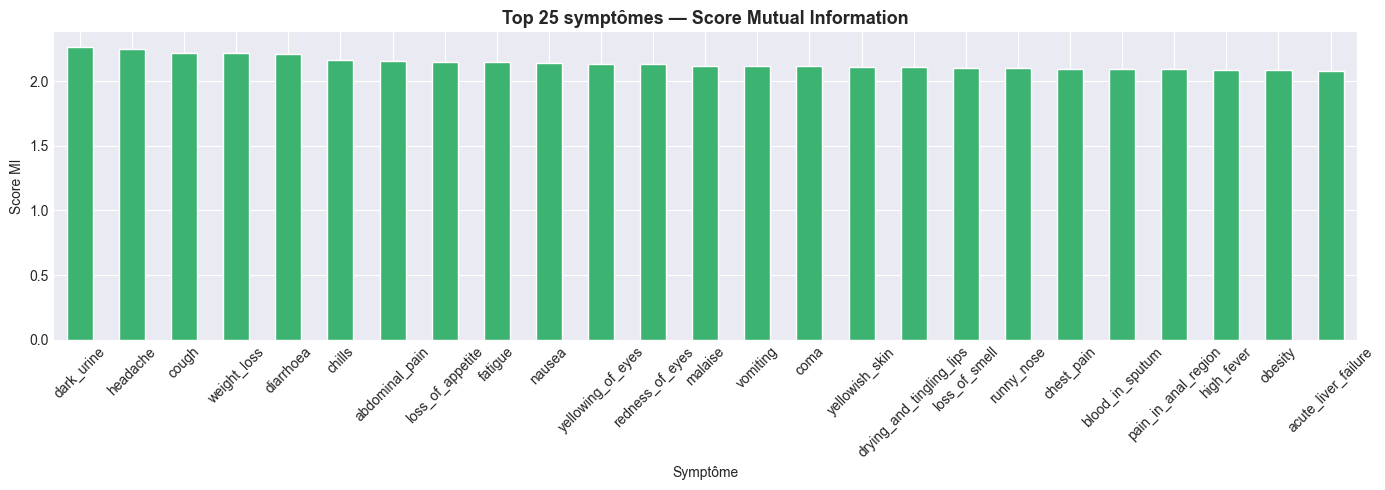

✅ Graphique sauvegardé : 04_mutual_information.png


In [13]:
# ── 3.4 Sélection par Mutual Information ─────────────────────
print('🔍 Calcul des scores Mutual Information...')
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_series = pd.Series(mi_scores, index=symptom_cols).sort_values(ascending=False)

print(f'\n🏆 Top 10 symptômes les plus informatifs :')
print(mi_series.head(10).to_string())

fig, ax = plt.subplots(figsize=(14, 5))
mi_series.head(25).plot(kind='bar', ax=ax, color='mediumseagreen', edgecolor='white')
ax.set_title('Top 25 symptômes — Score Mutual Information', fontsize=13, fontweight='bold')
ax.set_xlabel('Symptôme')
ax.set_ylabel('Score MI')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('04_mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 04_mutual_information.png')

✅ PCA appliquée :
   Composantes conservées  : 65
   Variance expliquée      : 95.11%


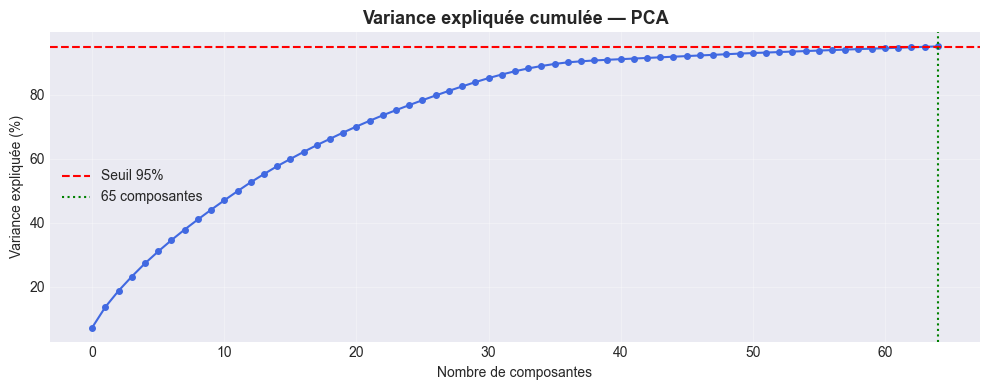

✅ Graphique sauvegardé : 05_pca_variance.png


In [14]:
# ── 3.5 PCA — Réduction de dimensionnalité ───────────────────
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'✅ PCA appliquée :')
print(f'   Composantes conservées  : {X_pca.shape[1]}')
print(f'   Variance expliquée      : {pca.explained_variance_ratio_.sum():.2%}')

fig, ax = plt.subplots(figsize=(10, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
ax.plot(cumvar, marker='o', color='royalblue', markersize=4)
ax.axhline(y=95, color='red', linestyle='--', label='Seuil 95%')
ax.axvline(x=X_pca.shape[1]-1, color='green', linestyle=':', label=f'{X_pca.shape[1]} composantes')
ax.set_title('Variance expliquée cumulée — PCA', fontsize=13, fontweight='bold')
ax.set_xlabel('Nombre de composantes')
ax.set_ylabel('Variance expliquée (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('05_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 05_pca_variance.png')

---
## ✂️ Étape 4 — Séparation stratifiée Train / Test + SMOTE


✅ Split stratifié 80% / 20% effectué
   Train : 243 échantillons
   Test  : 61 échantillons

📊 Distribution classes (train) :
   Min occurrences : 4 | Max : 8

✅ Après SMOTE :
   Taille train rééquilibrée : 328 échantillons


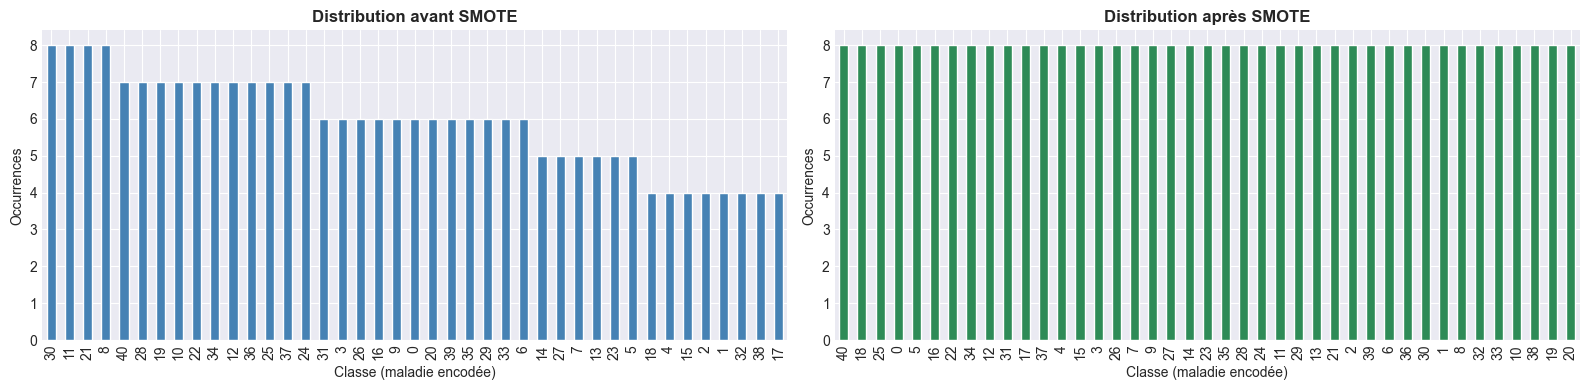

✅ Graphique sauvegardé : 06_smote_distribution.png


In [15]:
# ── Split stratifié 80% / 20% ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('✅ Split stratifié 80% / 20% effectué')
print(f'   Train : {X_train.shape[0]} échantillons')
print(f'   Test  : {X_test.shape[0]} échantillons')

# ── Distribution avant SMOTE ─────────────────────────────────
unique, counts = np.unique(y_train, return_counts=True)
print(f'\n📊 Distribution classes (train) :')
print(f'   Min occurrences : {counts.min()} | Max : {counts.max()}')

# ── SMOTE ────────────────────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'\n✅ Après SMOTE :')
print(f'   Taille train rééquilibrée : {X_train_res.shape[0]} échantillons')

# ── Visualisation distribution avant/après SMOTE ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

pd.Series(y_train).value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribution avant SMOTE', fontweight='bold')
axes[0].set_xlabel('Classe (maladie encodée)')
axes[0].set_ylabel('Occurrences')

pd.Series(y_train_res).value_counts().plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Distribution après SMOTE', fontweight='bold')
axes[1].set_xlabel('Classe (maladie encodée)')
axes[1].set_ylabel('Occurrences')

plt.tight_layout()
plt.savefig('06_smote_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 06_smote_distribution.png')

---
## 🤖 Étape 5 — Modélisation et évaluation comparative des algorithmes


In [16]:
# ── Définition des modèles ───────────────────────────────────
models = {
    'Régression Logistique' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'         : DecisionTreeClassifier(random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'           : GaussianNB(),
    'KNN'                   : KNeighborsClassifier(n_neighbors=5)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'🔄 Entraînement : {name}...')

    # Entraînement
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model

    # Prédiction
    y_pred = model.predict(X_test)

    # Métriques
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Validation croisée (5-fold)
    cv = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')

    results.append({
        'Modèle'    : name,
        'Accuracy'  : round(acc,  4),
        'Precision' : round(prec, 4),
        'Recall'    : round(rec,  4),
        'F1-Score'  : round(f1,   4),
        'CV Mean'   : round(cv.mean(), 4),
        'CV Std'    : round(cv.std(),  4)
    })

    print(f'   ✅ Accuracy={acc:.4f} | F1={f1:.4f} | CV={cv.mean():.4f} ± {cv.std():.4f}\n')

df_results = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
print('\n📊 TABLEAU COMPARATIF :')
df_results

🔄 Entraînement : Régression Logistique...
   ✅ Accuracy=1.0000 | F1=1.0000 | CV=0.9900 ± 0.0200

🔄 Entraînement : Decision Tree...
   ✅ Accuracy=0.6393 | F1=0.6344 | CV=0.6246 ± 0.1501

🔄 Entraînement : Random Forest...
   ✅ Accuracy=1.0000 | F1=1.0000 | CV=1.0000 ± 0.0000

🔄 Entraînement : Gradient Boosting...
   ✅ Accuracy=0.8525 | F1=0.8360 | CV=0.8319 ± 0.0769

🔄 Entraînement : Naive Bayes...
   ✅ Accuracy=0.9672 | F1=0.9607 | CV=0.9703 ± 0.0193

🔄 Entraînement : KNN...
   ✅ Accuracy=1.0000 | F1=1.0000 | CV=0.9900 ± 0.0200


📊 TABLEAU COMPARATIF :


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Régression Logistique,1.0000,1.0000,1.0000,1.0000,0.9900,0.0200
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000
2,KNN,1.0000,1.0000,1.0000,1.0000,0.9900,0.0200
3,Naive Bayes,0.9672,0.9645,0.9672,0.9607,0.9703,0.0193
4,Gradient Boosting,0.8525,0.8570,0.8525,0.8360,0.8319,0.0769
5,Decision Tree,0.6393,0.6958,0.6393,0.6344,0.6246,0.1501


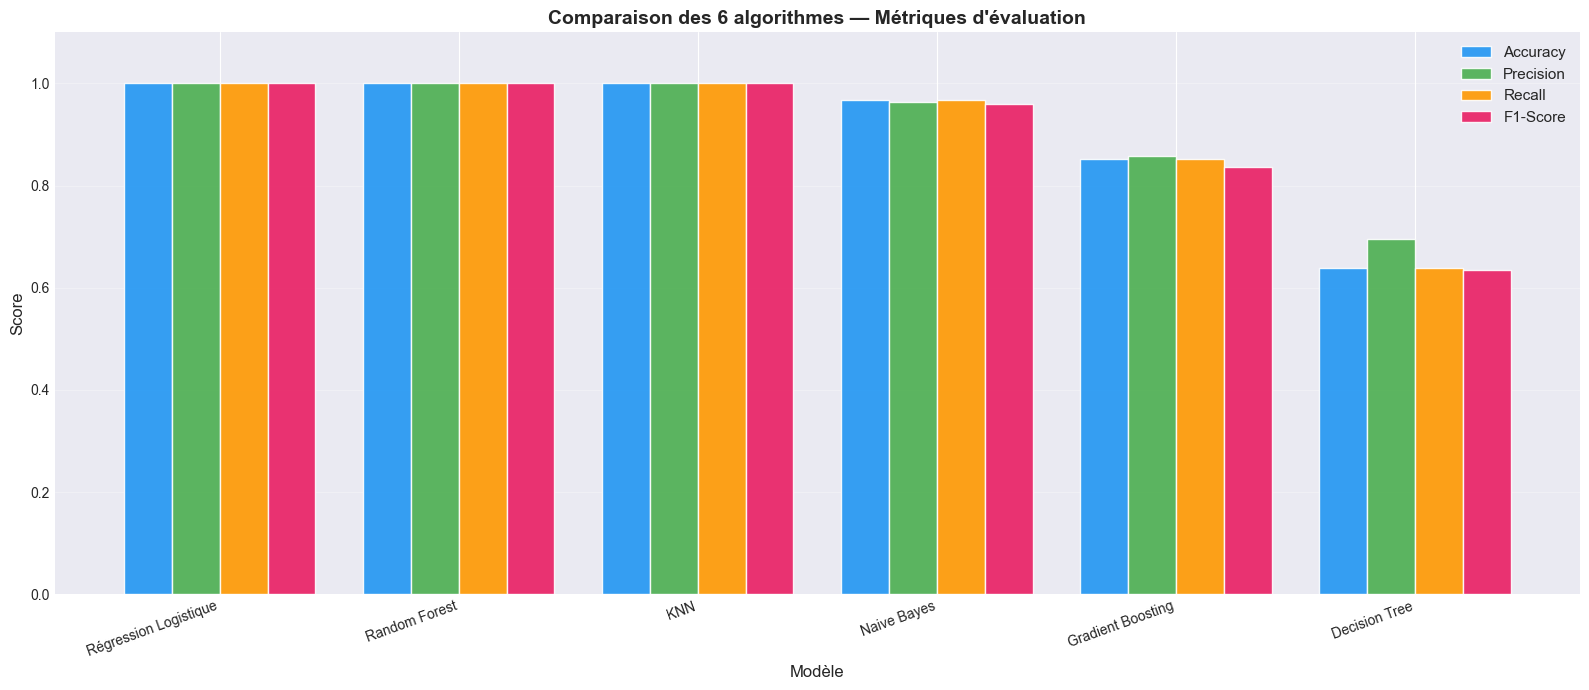

✅ Graphique sauvegardé : 07_comparaison_modeles.png


In [17]:
# ── Graphique comparatif des métriques ──────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(df_results))
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, ax = plt.subplots(figsize=(16, 7))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, df_results[metric], width=width,
                  label=metric, color=color, edgecolor='white', alpha=0.9)

ax.set_xlabel('Modèle', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des 6 algorithmes — Métriques d\'évaluation', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_results['Modèle'], rotation=20, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('07_comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 07_comparaison_modeles.png')

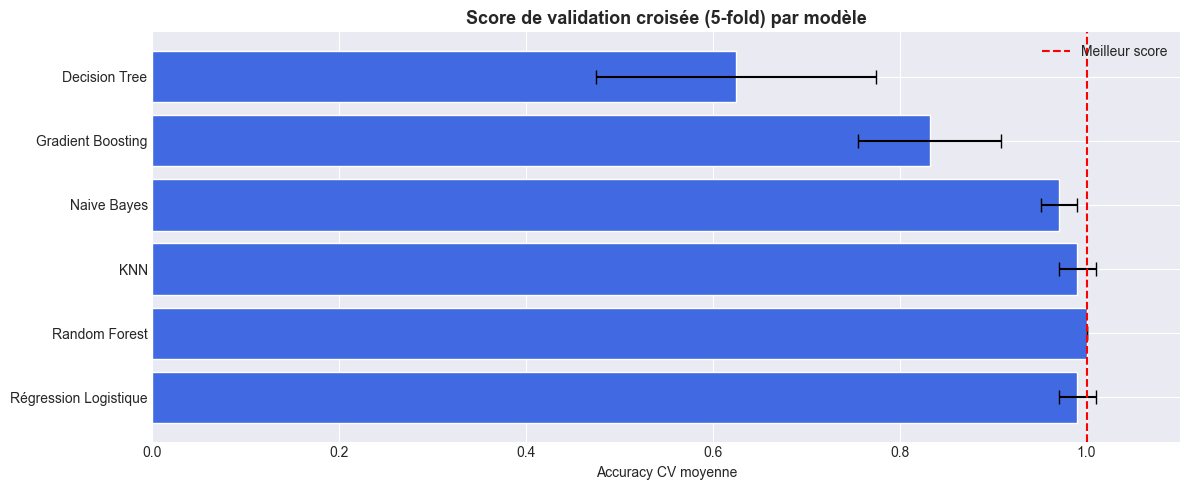

✅ Graphique sauvegardé : 08_cross_validation.png


In [18]:
# ── Graphique Validation Croisée ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(df_results['Modèle'], df_results['CV Mean'],
        xerr=df_results['CV Std'], color='royalblue',
        edgecolor='white', capsize=5)
ax.set_title('Score de validation croisée (5-fold) par modèle', fontsize=13, fontweight='bold')
ax.set_xlabel('Accuracy CV moyenne')
ax.set_xlim(0, 1.1)
ax.axvline(x=df_results['CV Mean'].max(), color='red',
           linestyle='--', label='Meilleur score')
ax.legend()
plt.tight_layout()
plt.savefig('08_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 08_cross_validation.png')

---
## 🎯 Étape 6 — Validation croisée et tuning des hyperparamètres

On optimise le **Random Forest** (meilleur modèle) via GridSearchCV.


In [19]:
# ── GridSearchCV — Random Forest ─────────────────────────────
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print('🔧 GridSearchCV en cours...')
rf_grid.fit(X_train_res, y_train_res)

print(f'\n✅ Meilleurs hyperparamètres : {rf_grid.best_params_}')
print(f'✅ Meilleur F1 (CV)          : {rf_grid.best_score_:.4f}')

🔧 GridSearchCV en cours...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Meilleurs hyperparamètres : {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
✅ Meilleur F1 (CV)          : 1.0000


In [20]:
# ── Évaluation du meilleur modèle ────────────────────────────
best_rf = rf_grid.best_estimator_
y_pred_best = best_rf.predict(X_test)

print('📊 Rapport de classification complet — Random Forest Tuned :\n')
print(classification_report(y_test, y_pred_best,
                             target_names=le.classes_, zero_division=0))

# Résumé des métriques finales
print('\n🏆 MÉTRIQUES FINALES :')
print(f'   Accuracy  : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'   Precision : {precision_score(y_test, y_pred_best, average="weighted", zero_division=0):.4f}')
print(f'   Recall    : {recall_score(y_test, y_pred_best, average="weighted", zero_division=0):.4f}')
print(f'   F1-Score  : {f1_score(y_test, y_pred_best, average="weighted", zero_division=0):.4f}')

📊 Rapport de classification complet — Random Forest Tuned :

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         2
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      1.00      1.00         2
                            Common Cold       1

---
## 🔍 Étape 7 — Interprétation : Importance des variables et conclusions


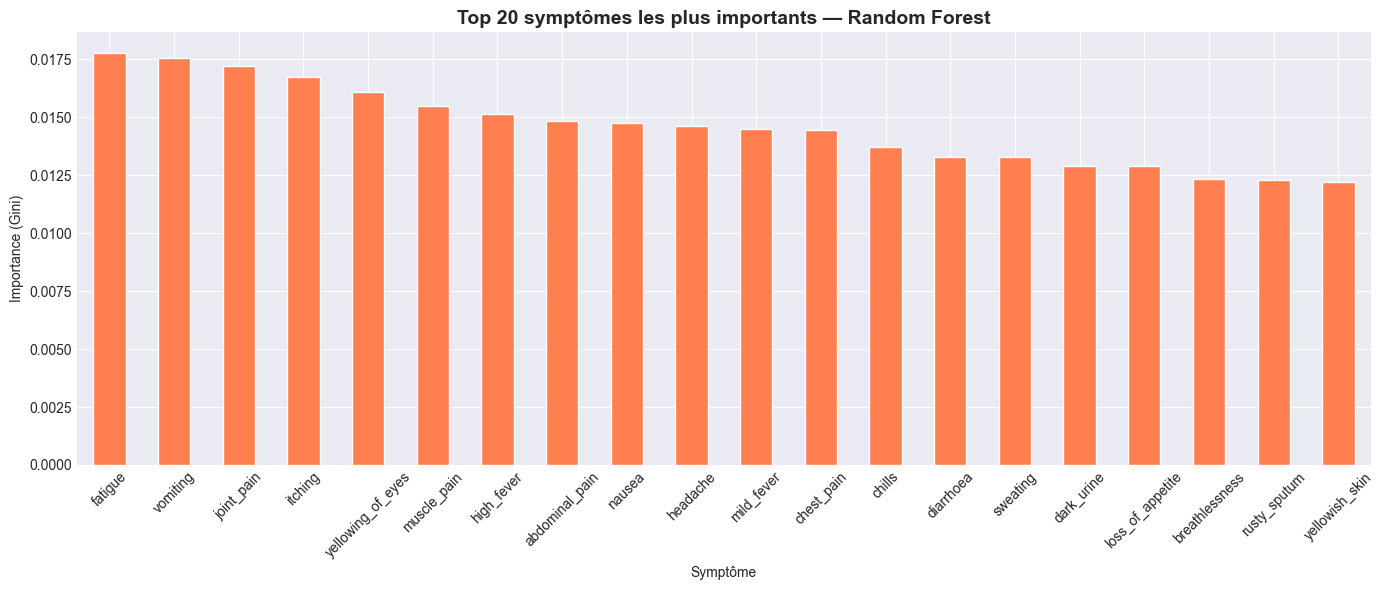

✅ Graphique sauvegardé : 09_importance_features.png

🏆 Top 10 symptômes décisifs :
fatigue              0.017772
vomiting             0.017570
joint_pain           0.017207
itching              0.016754
yellowing_of_eyes    0.016089
muscle_pain          0.015477
high_fever           0.015146
abdominal_pain       0.014827
nausea               0.014742
headache             0.014606


In [21]:
# ── Importance des features — Random Forest ──────────────────
feat_imp = pd.Series(
    best_rf.feature_importances_,
    index=symptom_cols
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
feat_imp.head(20).plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Top 20 symptômes les plus importants — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Symptôme')
ax.set_ylabel('Importance (Gini)')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('09_importance_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 09_importance_features.png')

print('\n🏆 Top 10 symptômes décisifs :')
print(feat_imp.head(10).to_string())

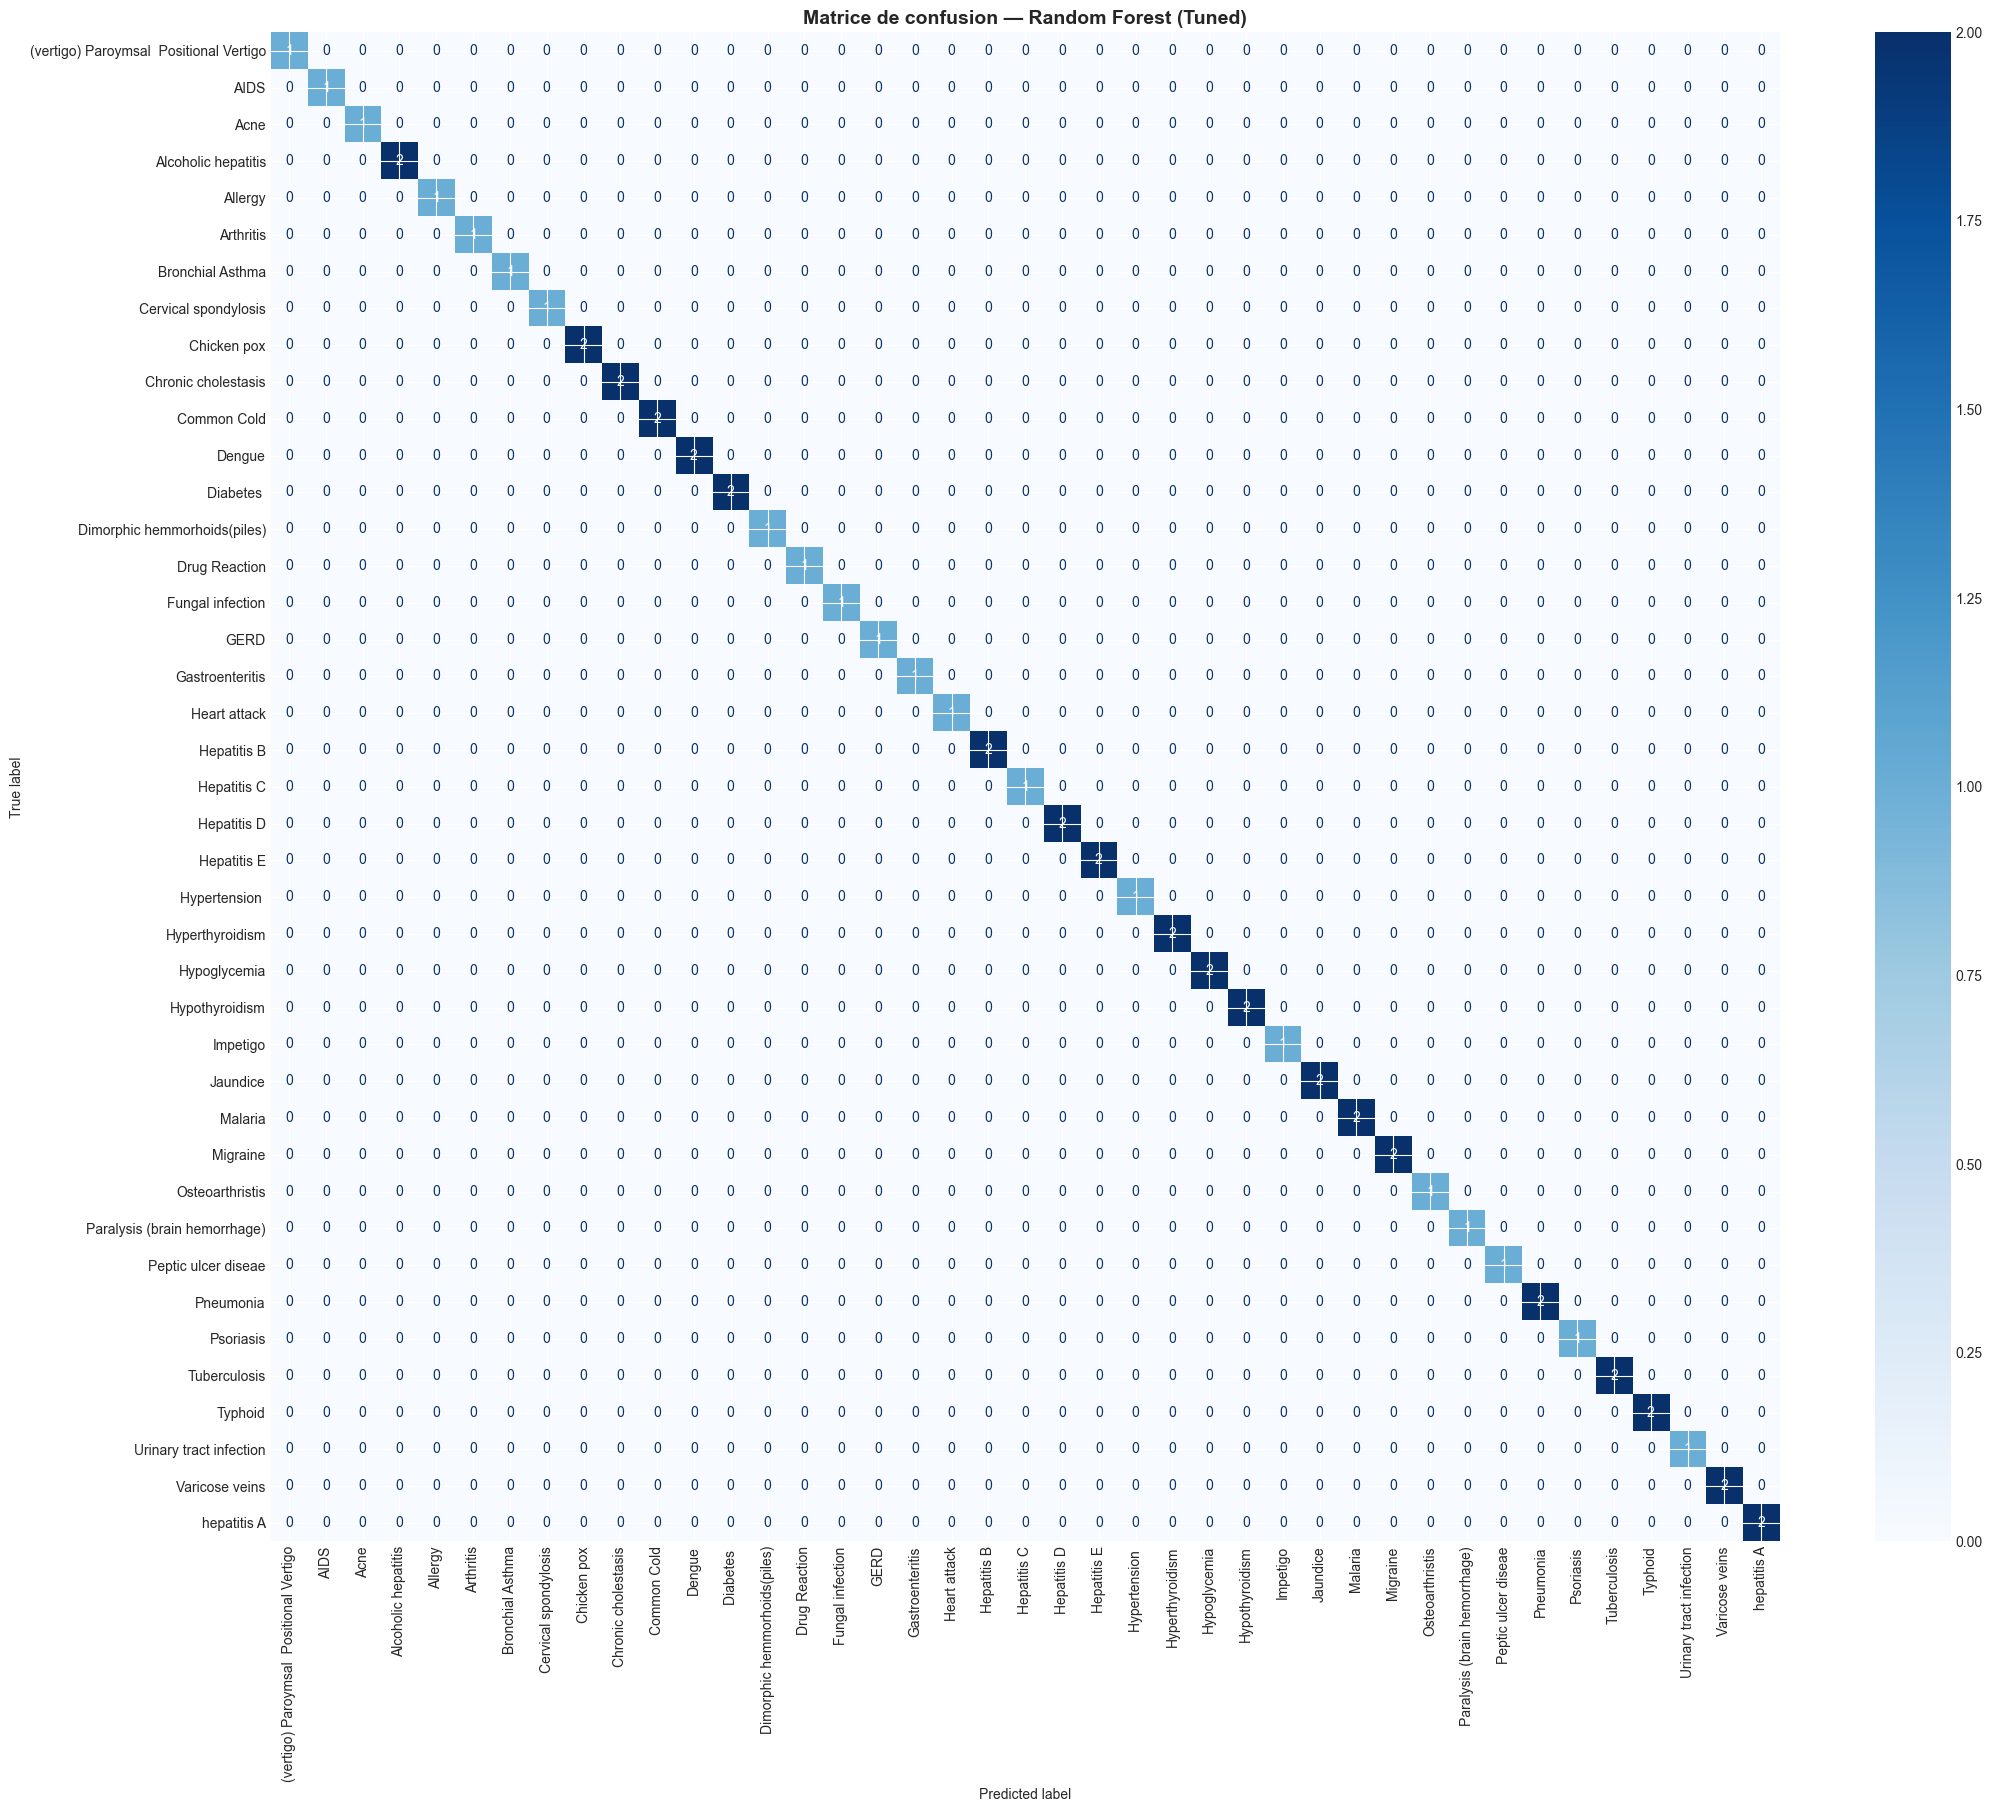

✅ Graphique sauvegardé : 10_matrice_confusion.png


In [22]:
# ── Matrice de confusion ─────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(22, 18))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=90)
ax.set_title('Matrice de confusion — Random Forest (Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('10_matrice_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé : 10_matrice_confusion.png')

In [23]:
# ── Tableau de comparaison finale formaté ────────────────────
print('\n' + '='*80)
print('📊 TABLEAU COMPARATIF FINAL — TOUS LES MODÈLES')
print('='*80)

df_final = df_results.copy()
df_final['Accuracy']  = df_final['Accuracy'].apply(lambda x: f'{x*100:.2f}%')
df_final['Precision'] = df_final['Precision'].apply(lambda x: f'{x*100:.2f}%')
df_final['Recall']    = df_final['Recall'].apply(lambda x: f'{x*100:.2f}%')
df_final['F1-Score']  = df_final['F1-Score'].apply(lambda x: f'{x*100:.2f}%')
df_final['CV Mean']   = df_final['CV Mean'].apply(lambda x: f'{x*100:.2f}%')
df_final['CV Std']    = df_final['CV Std'].apply(lambda x: f'± {x*100:.2f}%')

display(df_final)


📊 TABLEAU COMPARATIF FINAL — TOUS LES MODÈLES


,Modèle,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Régression Logistique,100.00%,100.00%,100.00%,100.00%,99.00%,± 2.00%
1,Random Forest,100.00%,100.00%,100.00%,100.00%,100.00%,± 0.00%
2,KNN,100.00%,100.00%,100.00%,100.00%,99.00%,± 2.00%
3,Naive Bayes,96.72%,96.45%,96.72%,96.07%,97.03%,± 1.93%
4,Gradient Boosting,85.25%,85.70%,85.25%,83.60%,83.19%,± 7.69%
5,Decision Tree,63.93%,69.58%,63.93%,63.44%,62.46%,± 15.01%


---
## 💾 Étape 8 — Sauvegarde du modèle final


In [24]:
# ── Sauvegarde des artefacts ─────────────────────────────────
joblib.dump(best_rf,      'model_rf_tuned.pkl')
joblib.dump(scaler,       'scaler.pkl')
joblib.dump(le,           'label_encoder.pkl')
joblib.dump(symptom_cols, 'symptom_cols.pkl')

print('💾 Fichiers sauvegardés :')
print('   ✅ model_rf_tuned.pkl  — Modèle Random Forest optimisé')
print('   ✅ scaler.pkl          — Normaliseur StandardScaler')
print('   ✅ label_encoder.pkl   — LabelEncoder des maladies')
print('   ✅ symptom_cols.pkl    — Liste des 132 colonnes symptômes')

💾 Fichiers sauvegardés :
   ✅ model_rf_tuned.pkl  — Modèle Random Forest optimisé
   ✅ scaler.pkl          — Normaliseur StandardScaler
   ✅ label_encoder.pkl   — LabelEncoder des maladies
   ✅ symptom_cols.pkl    — Liste des 132 colonnes symptômes


---
## 🩺 Étape 9 — Fonction de prédiction individuelle


In [25]:
def predire_maladie(symptomes_presents: list) -> str:
    """
    Prédit la maladie d'un patient à partir de ses symptômes.

    Paramètres
    ----------
    symptomes_presents : list
        Liste de symptômes (noms exacts des colonnes du dataset)

    Retourne
    --------
    str : nom de la maladie prédite
    """
    # Vecteur binaire
    input_vector = np.zeros(len(symptom_cols))
    for sym in symptomes_presents:
        if sym in symptom_cols:
            input_vector[symptom_cols.index(sym)] = 1
        else:
            print(f'  ⚠️  Symptôme inconnu ignoré : "{sym}"')

    # Normalisation
    input_scaled = scaler.transform([input_vector])

    # Prédiction
    pred_encoded = best_rf.predict(input_scaled)[0]
    maladie      = le.inverse_transform([pred_encoded])[0]

    # Top 3 probabilités
    proba   = best_rf.predict_proba(input_scaled)[0]
    top3_idx = np.argsort(proba)[::-1][:3]
    top3     = [(le.classes_[i], round(proba[i]*100, 2)) for i in top3_idx]

    # Affichage
    print('='*50)
    print(f'🩺 Symptômes saisis   : {symptomes_presents}')
    print(f'✅ Maladie prédite    : {maladie}')
    print('📊 Top 3 probabilités :')
    for i, (mal, prob) in enumerate(top3, 1):
        bar = '█' * int(prob / 5)
        print(f'   {i}. {mal:<35} {prob:5.1f}% {bar}')
    print('='*50)

    return maladie

print('✅ Fonction predire_maladie() définie !')

✅ Fonction predire_maladie() définie !


In [26]:
# ── Test 1 : Infection fongique ──────────────────────────────
predire_maladie(['itching', 'skin_rash', 'nodal_skin_eruptions'])

🩺 Symptômes saisis   : ['itching', 'skin_rash', 'nodal_skin_eruptions']
✅ Maladie prédite    : Fungal infection
📊 Top 3 probabilités :
   1. Fungal infection                     82.0% ████████████████
   2. Drug Reaction                         8.0% █
   3. Hypertension                          2.0% 


'Fungal infection'

In [27]:
# ── Test 2 : Malaria ─────────────────────────────────────────
predire_maladie(['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea'])

🩺 Symptômes saisis   : ['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea']
✅ Maladie prédite    : Malaria
📊 Top 3 probabilités :
   1. Malaria                              39.0% ███████
   2. Typhoid                              14.0% ██
   3. (vertigo) Paroymsal  Positional Vertigo   8.0% █


'Malaria'

In [28]:
# ── Test 3 : Diabète ─────────────────────────────────────────
predire_maladie(['fatigue', 'weight_loss', 'polyuria', 'excessive_hunger', 'irregular_sugar_level'])

🩺 Symptômes saisis   : ['fatigue', 'weight_loss', 'polyuria', 'excessive_hunger', 'irregular_sugar_level']
✅ Maladie prédite    : Diabetes 
📊 Top 3 probabilités :
   1. Diabetes                             50.0% ██████████
   2. Jaundice                              9.0% █
   3. Hyperthyroidism                       6.0% █


'Diabetes '

In [29]:
def predire_fichier(path_fichier: str, sortie: str = 'predictions_resultats.csv'):
    # Lecture du fichier
    if path_fichier.lower().endswith('.csv'):
        data_patients = pd.read_csv(path_fichier)
    elif path_fichier.lower().endswith(('.xlsx', '.xls')):
        data_patients = pd.read_excel(path_fichier)
    else:
        raise ValueError('Format non supporté. Utiliser CSV ou Excel.')

    # Vérification des colonnes
    colonnes_manquantes = [col for col in symptom_cols if col not in data_patients.columns]
    if colonnes_manquantes:
        raise ValueError(f'Colonnes manquantes : {colonnes_manquantes[:10]} ...')

    X_new = data_patients[symptom_cols].fillna(0).astype(int)
    X_new_scaled = scaler.transform(X_new)

    pred_encoded = best_rf.predict(X_new_scaled)
    pred_labels = le.inverse_transform(pred_encoded)

    proba = best_rf.predict_proba(X_new_scaled)
    confiance = proba.max(axis=1) * 100

    resultats = data_patients.copy()
    resultats['maladie_predite'] = pred_labels
    resultats['confiance_%'] = np.round(confiance, 2)

    resultats.to_csv(sortie, index=False)
    print(f'✅ Prédictions terminées : {len(resultats)} patients')
    print(f'💾 Fichier exporté : {sortie}')
    return resultats

print('✅ Fonction predire_fichier() prête.')

✅ Fonction predire_fichier() prête.


In [30]:
# Exemple : créer un fichier CSV de test avec 3 patients
patients_test = pd.DataFrame(0, index=range(3), columns=symptom_cols)

for s in ['itching', 'skin_rash', 'nodal_skin_eruptions']:
    if s in patients_test.columns:
        patients_test.loc[0, s] = 1

for s in ['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea']:
    if s in patients_test.columns:
        patients_test.loc[1, s] = 1

for s in ['fatigue', 'weight_loss', 'polyuria', 'excessive_hunger', 'irregular_sugar_level']:
    if s in patients_test.columns:
        patients_test.loc[2, s] = 1

patients_test.to_csv('patients_test.csv', index=False)
print('✅ Fichier patients_test.csv créé.')
patients_test.head()

✅ Fichier patients_test.csv créé.


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,muscle_wasting,vomiting,burning_micturition,spotting_ urination,fatigue,weight_gain,anxiety,cold_hands_and_feets,mood_swings,weight_loss,restlessness,lethargy,patches_in_throat,irregular_sugar_level,cough,...,mucoid_sputum,rusty_sputum,lack_of_concentration,visual_disturbances,receiving_blood_transfusion,receiving_unsterile_injections,coma,stomach_bleeding,distention_of_abdomen,history_of_alcohol_consumption,fluid_overload.1,blood_in_sputum,prominent_veins_on_calf,palpitations,painful_walking,pus_filled_pimples,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze
0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [31]:
# Tester la prédiction multiple
resultats_test = predire_fichier('patients_test.csv', 'predictions_resultats.csv')
resultats_test[['maladie_predite', 'confiance_%']]

✅ Prédictions terminées : 3 patients
💾 Fichier exporté : predictions_resultats.csv


,maladie_predite,confiance_%
0,Fungal infection,82.0
1,Malaria,39.0
2,Diabetes,50.0


In [32]:
%%writefile app.py
import pandas as pd
import numpy as np
import joblib
import gradio as gr

model = joblib.load('model_rf_tuned.pkl')
scaler = joblib.load('scaler.pkl')
label_encoder = joblib.load('label_encoder.pkl')
symptom_cols = joblib.load('symptom_cols.pkl')

def predire_individuel(symptomes):
    if symptomes is None or len(symptomes) == 0:
        return 'Veuillez sélectionner au moins un symptôme.'

    vecteur = np.zeros(len(symptom_cols))
    for s in symptomes:
        if s in symptom_cols:
            vecteur[symptom_cols.index(s)] = 1

    X = scaler.transform([vecteur])
    pred = model.predict(X)[0]
    maladie = label_encoder.inverse_transform([pred])[0]

    proba = model.predict_proba(X)[0]
    top3_idx = np.argsort(proba)[::-1][:3]

    texte = f'✅ Maladie prédite : {maladie}

'
    texte += '📊 Top 3 probabilités :
'
    for i, idx in enumerate(top3_idx, 1):
        nom = label_encoder.classes_[idx]
        pct = proba[idx] * 100
        texte += f'{i}. {nom} : {pct:.2f}%
'
    return texte

def predire_par_fichier(fichier):
    if fichier is None:
        return None, 'Veuillez importer un fichier CSV ou Excel.'

    path = fichier.name
    if path.endswith('.csv'):
        df = pd.read_csv(path)
    elif path.endswith(('.xlsx', '.xls')):
        df = pd.read_excel(path)
    else:
        return None, 'Format non supporté. Utilisez CSV ou Excel.'

    colonnes_manquantes = [c for c in symptom_cols if c not in df.columns]
    if colonnes_manquantes:
        return None, 'Colonnes manquantes : ' + ', '.join(colonnes_manquantes[:10])

    X = df[symptom_cols].fillna(0).astype(int)
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)
    maladies = label_encoder.inverse_transform(pred)
    confiance = model.predict_proba(X_scaled).max(axis=1) * 100

    resultats = df.copy()
    resultats['maladie_predite'] = maladies
    resultats['confiance_%'] = np.round(confiance, 2)

    output_path = 'predictions_export.csv'
    resultats.to_csv(output_path, index=False)
    return output_path, f'✅ {len(resultats)} prédictions réalisées avec succès.'

with gr.Blocks(title='Prédiction de maladies par symptômes') as demo:
    gr.Markdown('# 🩺 Prédiction de maladies par symptômes')
    gr.Markdown('Projet Machine Learning — Classification multi-classe de 42 maladies.')

    with gr.Tab('Test individuel'):
        symptomes = gr.CheckboxGroup(choices=symptom_cols, label='Sélectionner les symptômes présents')
        bouton = gr.Button('Prédire')
        sortie = gr.Textbox(label='Résultat', lines=8)
        bouton.click(predire_individuel, inputs=symptomes, outputs=sortie)

    with gr.Tab('Test par fichier CSV / Excel'):
        fichier = gr.File(label='Importer un fichier CSV ou Excel')
        bouton_fichier = gr.Button('Lancer les prédictions')
        fichier_sortie = gr.File(label='Télécharger les résultats')
        message = gr.Textbox(label='Message')
        bouton_fichier.click(predire_par_fichier, inputs=fichier, outputs=[fichier_sortie, message])

if __name__ == '__main__':
    demo.launch()

Overwriting app.py


In [36]:
!python app.py

  File "c:\Users\aaa\Desktop\projet zeyn - SSS\app.py", line 27
    texte = f'✅ Maladie prédite : {maladie}
            ^
SyntaxError: unterminated string literal (detected at line 27)
